# 05 — Review all 157 legacy event waveforms

This notebook follows:

```text
04_explore_manual_pick_clustering_updated.ipynb
```

and uses the epoch-precision legacy exports created by:

```text
/Users/thompsong/Developer/KSCRocketSeismology/matlab/fireball/
consolidate_spacex_matlab_legacy_data_epoch_complete.m
```

It generates one diagnostic PNG for each of the 157 events stored in
`catalog.mat`.

The plotting layout deliberately follows the publication style used by
`08_generate_paper_figures.ipynb`:

- three ground-velocity panels on the left;
- three acoustic-pressure panels on the right;
- shared relative-time axes;
- consistent scaling within the seismic and infrasound groups.

For catalogue review, the figures additionally show:

- the 157-event `ontime` and `offtime`;
- all nearby manual picks on their corresponding channels;
- phase labels and pick IDs;
- the closest 153-event interval for comparison;
- neighboring 157-event boundaries when they enter the plot window.

The purpose is visual quality control, not publication. All 157 figures are
generated, together with a CSV index, an HTML gallery, and optional contact
sheets.

Manual picks are now shown as **large solid orange circles with black
outlines**. Labels show only the original pick number, with a short
leader line to the waveform. The 157-event shaded interval is restricted
to the infrasound panels, while its solid boundary lines remain visible
on all six channels.

## 1. Imports and project paths

In [1]:
from pathlib import Path
import html
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
from obspy import Stream, UTCDateTime, read

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = (
    CURRENT_DIR.parent
    if CURRENT_DIR.name == "notebooks"
    else CURRENT_DIR
)

MODULE_DIR = PROJECT_ROOT / "modules"
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

from project_config import ensure_output_dirs

PATHS = ensure_output_dirs(PROJECT_ROOT)
DERIVED_DIR = PATHS["derived"]

LEGACY_EXPORT_DIR = PROJECT_ROOT / "metadata" / "legacy_export"

PICK_FILE = LEGACY_EXPORT_DIR / "manual_arrival_picks.csv"
CATALOG_153_FILE = (
    LEGACY_EXPORT_DIR / "legacy_infrasound_event_catalogue.csv"
)
CATALOG_157_FILE = (
    LEGACY_EXPORT_DIR / "legacy_catalog_157_events.csv"
)
REVIEW_LIST_FILE = (
    PROJECT_ROOT
    / "outputs"
    / "pick_clustering"
    / "derived"
    / "waveform_review_list.csv"
)

STREAM_FILE = DERIVED_DIR / "bchh_corrected_analysis_window.pkl"

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "event_waveform_review"
PNG_DIR = OUTPUT_DIR / "png"
CONTACT_SHEET_DIR = OUTPUT_DIR / "contact_sheets"

PNG_DIR.mkdir(parents=True, exist_ok=True)
CONTACT_SHEET_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 8.5,
    "axes.titlesize": 9.5,
    "axes.labelsize": 8.5,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "legend.fontsize": 7.5,
    "figure.dpi": 120,
})

print(f"Project root: {PROJECT_ROOT}")
print(f"Corrected stream: {STREAM_FILE}")
print(f"PNG output: {PNG_DIR}")

Project root: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper
Corrected stream: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/derived/bchh_corrected_analysis_window.pkl
PNG output: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/event_waveform_review/png


## 2. Configuration

The default review window begins 0.20 s before the 157-event onset and ends
0.30 s after its offset. This is wide enough to show the event, nearby picks,
and most close neighboring events without making each panel too compressed.

Set `WRITE_MULTIPAGE_PDF = True` to create a single 157-page PDF in addition
to the PNG files. PNG generation remains the primary output.

In [2]:
PRE_EVENT_S = 0.10
POST_EVENT_S = 0.50

# Manual picks shown within the plotted waveform window.
PICK_CONTEXT_S = 0.0

WRITE_ALL_PNGS = True
WRITE_MULTIPAGE_PDF = False
WRITE_CONTACT_SHEETS = True
WRITE_HTML_GALLERY = True

# Contact sheets contain reduced-size versions for rapid browsing.
CONTACT_SHEET_ROWS = 4
CONTACT_SHEET_COLUMNS = 4
CONTACT_SHEET_DPI = 180

SEISMIC_CHANNELS = ("HHZ", "HHN", "HHE")
INFRASOUND_CHANNELS = ("HD1", "HD2", "HD3")

SEISMIC_LABELS = {
    "HHZ": "Vertical",
    "HHN": "North",
    "HHE": "East",
}

# Pick display: all picks use prominent solid orange circles.
PICK_MARKER = "o"
PICK_MARKER_SIZE = 48
PICK_MARKER_COLOR = "tab:orange"
PICK_EDGE_COLOR = "black"
PICK_LABEL_ONLY_NUMBER = True
PICK_LABEL_ROTATION_DEG = 0

## 3. Load the corrected waveform stream and legacy metadata

In [3]:
for required_file in [
    STREAM_FILE,
    PICK_FILE,
    CATALOG_153_FILE,
    CATALOG_157_FILE,
]:
    if not required_file.exists():
        raise FileNotFoundError(
            f"Required input not found: {required_file}"
        )

st_corr = read(str(STREAM_FILE), format="PICKLE")
picks = pd.read_csv(PICK_FILE)
catalog_153 = pd.read_csv(CATALOG_153_FILE)
catalog_157 = pd.read_csv(CATALOG_157_FILE)

picks["arrival_time"] = pd.to_datetime(
    picks["arrivalTimeEpochS"],
    unit="s",
    utc=True,
)
picks["channel"] = (
    picks["channel"].astype(str).str.upper().str.strip()
)
picks["phase_normalized"] = (
    picks["phase"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.strip()
)

catalog_153["first_time"] = pd.to_datetime(
    catalog_153["firstArrivalEpochS"],
    unit="s",
    utc=True,
)
catalog_153["last_time"] = pd.to_datetime(
    catalog_153["lastArrivalEpochS"],
    unit="s",
    utc=True,
)

catalog_157["on_time"] = pd.to_datetime(
    catalog_157["onTimeEpochS"],
    unit="s",
    utc=True,
)
catalog_157["off_time"] = pd.to_datetime(
    catalog_157["offTimeEpochS"],
    unit="s",
    utc=True,
)

if REVIEW_LIST_FILE.exists():
    review_list = pd.read_csv(REVIEW_LIST_FILE)
    review_reason_map = (
        review_list
        .set_index("catalog157_event_number")["reasons"]
        .to_dict()
    )
else:
    review_list = pd.DataFrame()
    review_reason_map = {}

print(st_corr)
print(f"Manual picks: {len(picks)}")
print(f"153-event catalogue: {len(catalog_153)}")
print(f"157-event catalogue: {len(catalog_157)}")
print(f"Previously flagged review events: {len(review_reason_map)}")

6 Trace(s) in Stream:
FL.BCHH.00.HD1 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HD2 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HD3 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHE | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHN | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHZ | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
Manual picks: 890
153-event catalogue: 153
157-event catalogue: 157
Previously flagged review events: 68


## 4. Match each 157 event to its closest 153-event interval

Matching is based primarily on interval overlap. If no intervals overlap,
the nearest midpoint is used. This comparison is shown in every diagnostic
figure but does not determine the 157-event pick association.

In [4]:
def match_closest_catalog153(
    event157: pd.Series,
    catalog153: pd.DataFrame,
) -> dict:
    on_s = float(event157["onTimeEpochS"])
    off_s = float(event157["offTimeEpochS"])
    midpoint_s = 0.5 * (on_s + off_s)

    starts = catalog153["firstArrivalEpochS"].to_numpy(dtype=float)
    ends = catalog153["lastArrivalEpochS"].to_numpy(dtype=float)
    midpoints = 0.5 * (starts + ends)

    overlap_s = np.maximum(
        0.0,
        np.minimum(off_s, ends) - np.maximum(on_s, starts),
    )

    if np.any(overlap_s > 0):
        best_index = int(np.argmax(overlap_s))
        method = "maximum_overlap"
    else:
        best_index = int(np.argmin(np.abs(midpoints - midpoint_s)))
        method = "nearest_midpoint"

    row = catalog153.iloc[best_index]

    return {
        "event153": int(row["eventNumber"]),
        "match_method": method,
        "overlap_s": float(overlap_s[best_index]),
        "midpoint_difference_s": float(
            midpoints[best_index] - midpoint_s
        ),
        "start_difference_s": float(
            starts[best_index] - on_s
        ),
        "end_difference_s": float(
            ends[best_index] - off_s
        ),
    }


match_rows = []

for _, event157 in catalog_157.iterrows():
    match = match_closest_catalog153(event157, catalog_153)
    match_rows.append({
        "catalog157_event_number": int(
            event157["catalogEventNumber"]
        ),
        **match,
    })

matches_157_to_153 = pd.DataFrame(match_rows)

catalog_157 = catalog_157.merge(
    matches_157_to_153,
    left_on="catalogEventNumber",
    right_on="catalog157_event_number",
    how="left",
)

display(matches_157_to_153.head(15))

,catalog157_event_number,event153,match_method,overlap_s,midpoint_difference_s,start_difference_s,end_difference_s
0,1,1,maximum_overlap,0.088,0.0650,0.000,0.130
1,2,1,maximum_overlap,0.003,-0.0315,-0.139,0.076
2,3,3,maximum_overlap,0.012,0.0000,0.000,0.000
3,4,4,maximum_overlap,0.093,0.0000,0.000,0.000
4,5,5,nearest_midpoint,0.000,0.1020,0.115,0.089
5,6,6,nearest_midpoint,0.000,0.1295,0.173,0.086
6,7,6,nearest_midpoint,0.000,-0.1080,-0.086,-0.130
7,8,7,maximum_overlap,0.012,0.1395,0.000,0.279
8,9,8,maximum_overlap,0.084,0.0000,0.000,0.000
9,10,9,nearest_midpoint,0.000,0.0930,0.172,0.014


## 5. Plotting helpers

The review plot follows the six-panel style used by
`plot_key_event_waveforms`, but adds pick markers and catalogue boundaries.

Pick markers are placed directly on the waveform sample nearest the manual
pick time. A small label gives the phase and original pick ID.

In [5]:
def select_one_trace(
    stream: Stream,
    channel: str,
):
    matches = stream.select(channel=channel)
    if len(matches) != 1:
        raise ValueError(
            f"Expected exactly one {channel} trace; found {len(matches)}"
        )
    return matches[0]


def value_at_epoch_time(trace, epoch_s: float) -> tuple[float, float]:
    """Return nearest sample time and value for an epoch timestamp."""
    trace_start_s = float(trace.stats.starttime.timestamp)
    sample_index = int(
        round(
            (epoch_s - trace_start_s)
            * float(trace.stats.sampling_rate)
        )
    )
    sample_index = int(
        np.clip(sample_index, 0, trace.stats.npts - 1)
    )
    sample_epoch_s = (
        trace_start_s
        + sample_index / float(trace.stats.sampling_rate)
    )
    value = float(trace.data[sample_index])
    return sample_epoch_s, value


def nearby_catalog157_events(
    event_number: int,
    plot_start_epoch_s: float,
    plot_end_epoch_s: float,
) -> pd.DataFrame:
    return catalog_157.loc[
        (
            catalog_157["offTimeEpochS"]
            >= plot_start_epoch_s
        )
        & (
            catalog_157["onTimeEpochS"]
            <= plot_end_epoch_s
        )
        & (
            catalog_157["catalogEventNumber"]
            != event_number
        )
    ].copy()


def event_picks_in_window(
    plot_start_epoch_s: float,
    plot_end_epoch_s: float,
) -> pd.DataFrame:
    return picks.loc[
        picks["arrivalTimeEpochS"].between(
            plot_start_epoch_s - PICK_CONTEXT_S,
            plot_end_epoch_s + PICK_CONTEXT_S,
            inclusive="both",
        )
        & picks["channel"].isin(
            list(SEISMIC_CHANNELS) + list(INFRASOUND_CHANNELS)
        )
    ].copy()


def summarize_pick_counts(pick_table: pd.DataFrame) -> dict:
    phase = pick_table["phase_normalized"]

    return {
        "manual_pick_count": len(pick_table),
        "n_phase_count": int((phase == "n").sum()),
        "deleted_pick_count": int((phase == "del").sum()),
        "seismic_pick_count": int(
            pick_table["channel"].isin(SEISMIC_CHANNELS).sum()
        ),
        "infrasound_pick_count": int(
            pick_table["channel"].isin(INFRASOUND_CHANNELS).sum()
        ),
    }


def build_review_figure(
    event157: pd.Series,
    stream: Stream,
):
    event_number = int(event157["catalogEventNumber"])
    on_epoch_s = float(event157["onTimeEpochS"])
    off_epoch_s = float(event157["offTimeEpochS"])

    plot_start_epoch_s = on_epoch_s - PRE_EVENT_S
    plot_end_epoch_s = off_epoch_s + POST_EVENT_S

    plot_start = UTCDateTime(plot_start_epoch_s)
    plot_end = UTCDateTime(plot_end_epoch_s)
    reference_time = UTCDateTime(on_epoch_s)

    event_stream = stream.copy().trim(
        plot_start,
        plot_end,
        pad=False,
    )

    seismic = [
        select_one_trace(event_stream, channel)
        for channel in SEISMIC_CHANNELS
    ]
    pressure = [
        select_one_trace(event_stream, channel)
        for channel in INFRASOUND_CHANNELS
    ]

    fig = plt.figure(
        figsize=(12.2, 7.4),
        constrained_layout=True,
    )
    grid = fig.add_gridspec(
        3,
        2,
        width_ratios=(1.0, 1.25),
        wspace=0.08,
        hspace=0.05,
    )
    seismic_axes = [
        fig.add_subplot(grid[i, 0])
        for i in range(3)
    ]
    pressure_axes = [
        fig.add_subplot(grid[i, 1])
        for i in range(3)
    ]

    seismic_limit = max(
        np.nanmax(np.abs(tr.data.astype(float)))
        for tr in seismic
    )
    seismic_limit = max(seismic_limit * 1.08, 1e-12)

    pressure_arrays = {
        tr.stats.channel: tr.data.astype(float)
        for tr in pressure
    }
    pressure_min = min(
        np.nanmin(values)
        for values in pressure_arrays.values()
    )
    pressure_max = max(
        np.nanmax(values)
        for values in pressure_arrays.values()
    )
    pressure_padding = 0.05 * max(
        pressure_max - pressure_min,
        1.0,
    )

    axes_by_channel = {}

    for index, (axis, trace) in enumerate(
        zip(seismic_axes, seismic)
    ):
        relative_time_s = trace.times(
            reftime=reference_time
        )
        axis.plot(
            relative_time_s,
            trace.data.astype(float),
            linewidth=0.9,
        )
        axis.axhline(0.0, linewidth=0.5, alpha=0.5)
        axis.set_ylim(-seismic_limit, seismic_limit)
        axis.yaxis.set_major_locator(MaxNLocator(nbins=4))
        axis.text(
            0.02,
            0.86,
            SEISMIC_LABELS.get(
                trace.stats.channel,
                trace.stats.channel,
            ),
            transform=axis.transAxes,
            fontweight="bold",
            va="top",
        )
        if index < 2:
            axis.tick_params(labelbottom=False)
        axis.spines[["top", "right"]].set_visible(False)
        axes_by_channel[trace.stats.channel] = (
            axis,
            trace,
        )

    for index, (axis, trace) in enumerate(
        zip(pressure_axes, pressure)
    ):
        relative_time_s = trace.times(
            reftime=reference_time
        )
        axis.plot(
            relative_time_s,
            pressure_arrays[trace.stats.channel],
            linewidth=1.0,
        )
        axis.axhline(0.0, linewidth=0.5, alpha=0.5)
        axis.set_ylim(
            pressure_min - pressure_padding,
            pressure_max + pressure_padding,
        )
        axis.yaxis.set_major_locator(MaxNLocator(nbins=5))
        axis.text(
            0.02,
            0.86,
            trace.stats.channel,
            transform=axis.transAxes,
            fontweight="bold",
            va="top",
        )
        if index < 2:
            axis.tick_params(labelbottom=False)
        axis.spines[["top", "right"]].set_visible(False)
        axes_by_channel[trace.stats.channel] = (
            axis,
            trace,
        )

    all_axes = seismic_axes + pressure_axes

    relative_plot_start_s = plot_start_epoch_s - on_epoch_s
    relative_plot_end_s = plot_end_epoch_s - on_epoch_s
    relative_off_s = off_epoch_s - on_epoch_s

    # Current 157-event interval: shaded only on the infrasound panels.
    for axis in pressure_axes:
        axis.axvspan(
            0.0,
            relative_off_s,
            alpha=0.14,
            zorder=0,
        )

    # Current 157-event boundaries on all panels.
    for axis in all_axes:
        axis.axvline(
            0.0,
            linewidth=1.3,
            linestyle="-",
            zorder=2,
        )
        axis.axvline(
            relative_off_s,
            linewidth=1.3,
            linestyle="-",
            zorder=2,
        )

    # Closest 153-event interval.
    event153_number = int(event157["event153"])
    event153 = catalog_153.loc[
        catalog_153["eventNumber"] == event153_number
    ].iloc[0]

    event153_start_relative_s = (
        float(event153["firstArrivalEpochS"])
        - on_epoch_s
    )
    event153_end_relative_s = (
        float(event153["lastArrivalEpochS"])
        - on_epoch_s
    )

    for axis in all_axes:
        axis.axvline(
            event153_start_relative_s,
            linestyle="--",
            linewidth=1.0,
            alpha=0.95,
        )
        axis.axvline(
            event153_end_relative_s,
            linestyle="--",
            linewidth=1.0,
            alpha=0.95,
        )

    # Neighboring 157-event boundaries.
    neighbors = nearby_catalog157_events(
        event_number,
        plot_start_epoch_s,
        plot_end_epoch_s,
    )

    for neighbor in neighbors.itertuples(index=False):
        neighbor_on_relative_s = (
            neighbor.onTimeEpochS - on_epoch_s
        )
        neighbor_off_relative_s = (
            neighbor.offTimeEpochS - on_epoch_s
        )
        for axis in all_axes:
            axis.axvline(
                neighbor_on_relative_s,
                linestyle=":",
                linewidth=0.75,
                alpha=0.7,
            )
            axis.axvline(
                neighbor_off_relative_s,
                linestyle=":",
                linewidth=0.75,
                alpha=0.7,
            )

    nearby_picks = event_picks_in_window(
        plot_start_epoch_s,
        plot_end_epoch_s,
    )
    pick_counts = summarize_pick_counts(nearby_picks)

    # Manual picks: prominent solid orange circles with black edges.
    for pick in nearby_picks.itertuples(index=False):
        if pick.channel not in axes_by_channel:
            continue

        axis, trace = axes_by_channel[pick.channel]
        sample_epoch_s, sample_value = value_at_epoch_time(
            trace,
            float(pick.arrivalTimeEpochS),
        )
        relative_pick_s = sample_epoch_s - on_epoch_s

        axis.scatter(
            [relative_pick_s],
            [sample_value],
            marker=PICK_MARKER,
            s=PICK_MARKER_SIZE,
            facecolors=PICK_MARKER_COLOR,
            edgecolors=PICK_EDGE_COLOR,
            linewidths=0.7,
            zorder=7,
        )

        label = (
            f"{int(pick.pickIndex)}"
            if PICK_LABEL_ONLY_NUMBER
            else f"{pick.phase_normalized.upper()}:{int(pick.pickIndex)}"
        )

        axis.annotate(
            label,
            (relative_pick_s, sample_value),
            xytext=(4, 6),
            textcoords="offset points",
            fontsize=6.5,
            rotation=PICK_LABEL_ROTATION_DEG,
            ha="left",
            va="bottom",
            zorder=8,
            arrowprops={
                "arrowstyle": "-",
                "linewidth": 0.45,
                "shrinkA": 0,
                "shrinkB": 3,
            },
        )

    for axis in all_axes:
        axis.set_xlim(
            relative_plot_start_s,
            relative_plot_end_s,
        )
        axis.grid(
            axis="x",
            linewidth=0.4,
            alpha=0.3,
        )

    seismic_axes[0].set_title(
        "Ground velocity",
        fontweight="bold",
    )
    pressure_axes[0].set_title(
        "Acoustic pressure",
        fontweight="bold",
    )
    seismic_axes[1].set_ylabel(
        "Ground velocity (m s$^{-1}$)"
    )
    pressure_axes[1].set_ylabel("Pressure (Pa)")

    reference_label = reference_time.strftime(
        "%H:%M:%S.%f"
    )[:-3]
    xlabel = (
        f"Time relative to 157-event onset "
        f"{reference_label} UTC (s)"
    )
    seismic_axes[-1].set_xlabel(xlabel)
    pressure_axes[-1].set_xlabel(xlabel)

    duration153_s = (
        float(event153["lastArrivalEpochS"])
        - float(event153["firstArrivalEpochS"])
    )

    reasons = review_reason_map.get(event_number, "")
    reason_suffix = (
        f"\nReview flags: {reasons}"
        if reasons
        else ""
    )

    title = (
        f"157-event {event_number:03d}: "
        f"{event157['on_time'].strftime('%H:%M:%S.%f')[:-3]}–"
        f"{event157['off_time'].strftime('%H:%M:%S.%f')[:-3]} UTC; "
        f"duration {float(event157['durationS']):.3f} s\n"
        f"Closest 153-event: {event153_number}; "
        f"duration {duration153_s:.3f} s; "
        f"overlap {float(event157['overlap_s']):.3f} s"
        f"{reason_suffix}"
    )
    fig.suptitle(title, fontweight="bold")

    summary_text = (
        f"Manual picks: {pick_counts['manual_pick_count']}\n"
        f"N picks: {pick_counts['n_phase_count']}\n"
        f"Deleted: {pick_counts['deleted_pick_count']}\n"
        f"Seismic: {pick_counts['seismic_pick_count']}\n"
        f"Infrasound: {pick_counts['infrasound_pick_count']}\n"
        f"157 duration: {float(event157['durationS']):.3f} s\n"
        f"153 duration: {duration153_s:.3f} s"
    )

    fig.text(
        0.995,
        0.965,
        summary_text,
        ha="right",
        va="top",
        fontsize=7.4,
        bbox={
            "boxstyle": "round,pad=0.35",
            "facecolor": "white",
            "edgecolor": "0.65",
            "alpha": 0.95,
        },
    )

    legend_handles = [
        Line2D(
            [0],
            [0],
            linestyle="-",
            linewidth=1.3,
            label="157-event boundary",
        ),
        Line2D(
            [0],
            [0],
            linestyle="--",
            linewidth=1.0,
            label="Closest 153-event boundary",
        ),
        Line2D(
            [0],
            [0],
            linestyle=":",
            linewidth=0.75,
            label="Neighboring 157-event boundary",
        ),
        Line2D(
            [0],
            [0],
            marker=PICK_MARKER,
            linestyle="None",
            markerfacecolor=PICK_MARKER_COLOR,
            markeredgecolor=PICK_EDGE_COLOR,
            markersize=7,
            label="Manual pick",
        ),
    ]

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=4,
        bbox_to_anchor=(0.5, -0.012),
        frameon=False,
    )

    metadata = {
        "event_number": event_number,
        "on_time": event157["on_time"],
        "off_time": event157["off_time"],
        "duration_s": float(event157["durationS"]),
        "event153": event153_number,
        "match_method": event157["match_method"],
        "overlap_s": float(event157["overlap_s"]),
        "nearby_pick_count": len(nearby_picks),
        "n_phase_pick_count": pick_counts["n_phase_count"],
        "deleted_pick_count": pick_counts["deleted_pick_count"],
        "seismic_pick_count": pick_counts["seismic_pick_count"],
        "infrasound_pick_count": pick_counts["infrasound_pick_count"],
        "neighbor_event_numbers": ",".join(
            neighbors["catalogEventNumber"]
            .astype(int)
            .astype(str)
        ),
        "review_reasons": reasons,
    }

    return fig, metadata

## 6. Preview one event

Generate one figure interactively before committing to all 157 files.
Change `PREVIEW_EVENT_NUMBER` to inspect a particular event.

{'event_number': 1, 'on_time': Timestamp('2016-09-01 13:07:15.927999973+0000', tz='UTC'), 'off_time': Timestamp('2016-09-01 13:07:16.016000032+0000', tz='UTC'), 'duration_s': 0.0879999250173569, 'event153': 1, 'match_method': 'maximum_overlap', 'overlap_s': 0.08800005912780762, 'nearby_pick_count': 11, 'neighbor_event_numbers': '2', 'review_reasons': 'end differs from 153 by >0.05 s; possible split from 153 catalogue'}


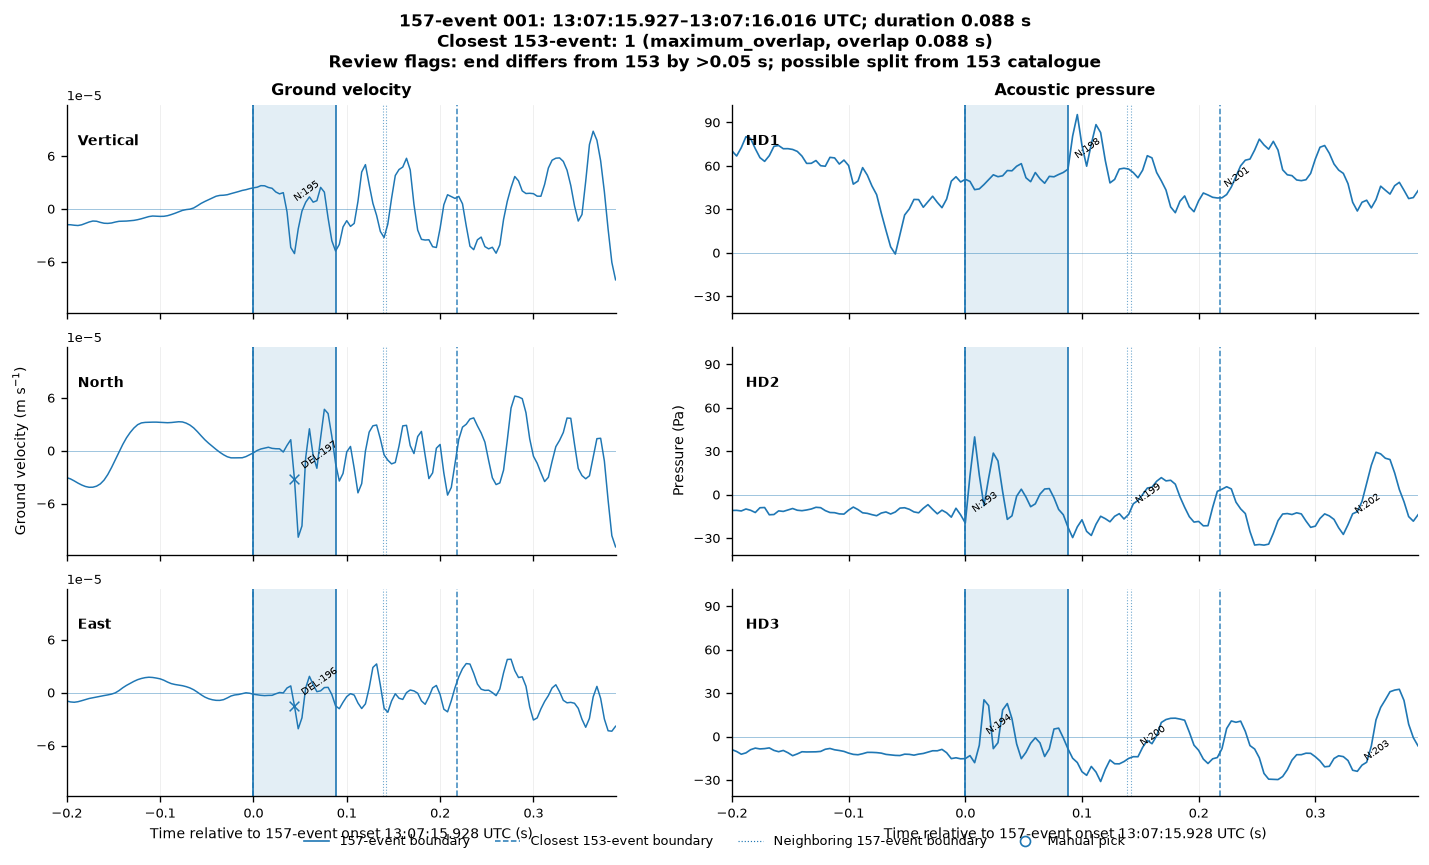

In [6]:
PREVIEW_EVENT_NUMBER = 1

preview_event = catalog_157.loc[
    catalog_157["catalogEventNumber"]
    == PREVIEW_EVENT_NUMBER
].iloc[0]

preview_figure, preview_metadata = build_review_figure(
    preview_event,
    st_corr,
)

print(preview_metadata)
plt.show()

## 7. Generate all 157 PNG files

Files are named chronologically:

```text
event_001_130715928.png
...
event_157_133407417.png
```

In [7]:
output_rows = []

pdf_path = OUTPUT_DIR / "all_157_event_waveforms.pdf"
pdf_context = (
    PdfPages(pdf_path)
    if WRITE_MULTIPAGE_PDF
    else None
)

try:
    for row_number, event157 in catalog_157.iterrows():
        event_number = int(event157["catalogEventNumber"])
        timestamp_text = event157["on_time"].strftime(
            "%H%M%S%f"
        )[:9]

        png_name = (
            f"event_{event_number:03d}_{timestamp_text}.png"
        )
        png_path = PNG_DIR / png_name

        figure, metadata = build_review_figure(
            event157,
            st_corr,
        )

        if WRITE_ALL_PNGS:
            figure.savefig(
                png_path,
                dpi=220,
                bbox_inches="tight",
            )

        if pdf_context is not None:
            pdf_context.savefig(
                figure,
                bbox_inches="tight",
            )

        plt.close(figure)

        output_rows.append({
            **metadata,
            "png_file": png_name,
            "png_path": str(png_path),
        })

        if (
            event_number == 1
            or event_number % 10 == 0
            or event_number == len(catalog_157)
        ):
            print(
                f"Generated event {event_number:03d} "
                f"of {len(catalog_157)}"
            )
finally:
    if pdf_context is not None:
        pdf_context.close()

event_figure_index = pd.DataFrame(output_rows)
event_figure_index.to_csv(
    OUTPUT_DIR / "event_figure_index.csv",
    index=False,
)

display(event_figure_index.head())
print(f"Generated {len(event_figure_index)} event figures.")

Generated event 001 of 157
Generated event 010 of 157
Generated event 020 of 157
Generated event 030 of 157
Generated event 040 of 157
Generated event 050 of 157
Generated event 060 of 157
Generated event 070 of 157
Generated event 080 of 157
Generated event 090 of 157
Generated event 100 of 157
Generated event 110 of 157
Generated event 120 of 157
Generated event 130 of 157
Generated event 140 of 157
Generated event 150 of 157
Generated event 157 of 157


,event_number,on_time,off_time,duration_s,event153,match_method,overlap_s,nearby_pick_count,neighbor_event_numbers,review_reasons,png_file,png_path
0,1,2016-09-01 13:07:15.927999973+00:00,2016-09-01 13:07:16.016000032+00:00,0.088000,1,maximum_overlap,0.088,11,2,end differs from 153 by >0.05 s; possible spli...,event_001_130715927.png,/Users/thompsong/Developer/KSCRocketSeismology...
1,2,2016-09-01 13:07:16.066999911+00:00,2016-09-01 13:07:16.069999933+00:00,0.002997,1,maximum_overlap,0.003,12,1,end differs from 153 by >0.05 s; possible spli...,event_002_130716066.png,/Users/thompsong/Developer/KSCRocketSeismology...
2,3,2016-09-01 13:07:16.799999952+00:00,2016-09-01 13:07:16.812000036+00:00,0.012000,3,maximum_overlap,0.012,2,,,event_003_130716799.png,/Users/thompsong/Developer/KSCRocketSeismology...
3,4,2016-09-01 13:07:17.242000103+00:00,2016-09-01 13:07:17.335000038+00:00,0.092999,4,maximum_overlap,0.093,5,5,,event_004_130717242.png,/Users/thompsong/Developer/KSCRocketSeismology...
4,5,2016-09-01 13:07:17.519000052+00:00,2016-09-01 13:07:17.634000063+00:00,0.115006,5,nearest_midpoint,0.000,7,"4,6",end differs from 153 by >0.05 s; fewer than tw...,event_005_130717519.png,/Users/thompsong/Developer/KSCRocketSeismology...


Generated 157 event figures.


## 8. Generate contact sheets

Contact sheets are useful for a first rapid scan. Each page shows 16 event
images. The full-resolution PNGs remain available for closer inspection.

In [8]:
if WRITE_CONTACT_SHEETS:
    from PIL import Image, ImageDraw, ImageFont

    image_paths = [
        PNG_DIR / filename
        for filename in event_figure_index["png_file"]
    ]

    images_per_sheet = (
        CONTACT_SHEET_ROWS * CONTACT_SHEET_COLUMNS
    )

    contact_sheet_rows = []

    for sheet_start in range(
        0,
        len(image_paths),
        images_per_sheet,
    ):
        sheet_paths = image_paths[
            sheet_start:sheet_start + images_per_sheet
        ]

        thumbnails = []

        for image_path in sheet_paths:
            with Image.open(image_path) as image:
                image = image.convert("RGB")
                image.thumbnail((700, 420))
                thumbnails.append(
                    (image.copy(), image_path.name)
                )

        cell_width = max(
            image.width for image, _ in thumbnails
        )
        cell_height = max(
            image.height for image, _ in thumbnails
        ) + 26

        canvas = Image.new(
            "RGB",
            (
                CONTACT_SHEET_COLUMNS * cell_width,
                CONTACT_SHEET_ROWS * cell_height,
            ),
            "white",
        )
        draw = ImageDraw.Draw(canvas)

        for index, (image, filename) in enumerate(thumbnails):
            row = index // CONTACT_SHEET_COLUMNS
            column = index % CONTACT_SHEET_COLUMNS

            x = column * cell_width
            y = row * cell_height

            canvas.paste(image, (x, y))
            draw.text(
                (x + 5, y + image.height + 3),
                filename,
                fill="black",
            )

        first_event = sheet_start + 1
        last_event = sheet_start + len(sheet_paths)

        sheet_name = (
            f"events_{first_event:03d}_to_"
            f"{last_event:03d}.jpg"
        )
        sheet_path = CONTACT_SHEET_DIR / sheet_name

        canvas.save(
            sheet_path,
            quality=90,
            dpi=(
                CONTACT_SHEET_DPI,
                CONTACT_SHEET_DPI,
            ),
        )

        contact_sheet_rows.append({
            "first_event": first_event,
            "last_event": last_event,
            "contact_sheet_file": sheet_name,
            "contact_sheet_path": str(sheet_path),
        })

    contact_sheet_index = pd.DataFrame(
        contact_sheet_rows
    )
    contact_sheet_index.to_csv(
        OUTPUT_DIR / "contact_sheet_index.csv",
        index=False,
    )

    print(
        f"Generated {len(contact_sheet_index)} contact sheets."
    )
else:
    print("Contact-sheet generation disabled.")

Generated 10 contact sheets.


## 9. Generate an HTML gallery

Open `event_waveform_gallery.html` in a browser. Each thumbnail links to the
full-resolution PNG and includes the event time, closest 153-event match,
and any review flags.

In [9]:
if WRITE_HTML_GALLERY:
    html_path = OUTPUT_DIR / "event_waveform_gallery.html"

    cards = []

    for row in event_figure_index.itertuples(index=False):
        relative_image_path = (
            Path("png") / row.png_file
        )

        reason_text = (
            html.escape(str(row.review_reasons))
            if str(row.review_reasons)
            else "No prior review flags"
        )

        cards.append(
            f"""
            <article class="card">
              <a href="{relative_image_path.as_posix()}">
                <img src="{relative_image_path.as_posix()}"
                     alt="Event {row.event_number:03d}">
              </a>
              <h2>Event {row.event_number:03d}</h2>
              <p>
                {row.on_time} to {row.off_time}<br>
                Duration: {row.duration_s:.3f} s<br>
                Closest 153-event: {row.event153}<br>
                Nearby picks: {row.nearby_pick_count}
              </p>
              <p class="flags">{reason_text}</p>
            </article>
            """
        )

    document = f"""
    <!doctype html>
    <html lang="en">
    <head>
      <meta charset="utf-8">
      <meta name="viewport"
            content="width=device-width, initial-scale=1">
      <title>Falcon 9 event waveform review</title>
      <style>
        body {{
          font-family: -apple-system, BlinkMacSystemFont,
                       "Segoe UI", sans-serif;
          margin: 1.5rem;
          background: #f4f4f4;
          color: #222;
        }}
        h1 {{ margin-bottom: 0.3rem; }}
        .intro {{ max-width: 70rem; }}
        .grid {{
          display: grid;
          grid-template-columns:
            repeat(auto-fit, minmax(360px, 1fr));
          gap: 1rem;
          align-items: start;
        }}
        .card {{
          background: white;
          border: 1px solid #ddd;
          border-radius: 8px;
          padding: 0.75rem;
          box-shadow: 0 1px 3px rgba(0,0,0,0.08);
        }}
        .card img {{
          width: 100%;
          height: auto;
          display: block;
          border: 1px solid #eee;
        }}
        .card h2 {{
          font-size: 1rem;
          margin: 0.65rem 0 0.25rem;
        }}
        .card p {{
          font-size: 0.86rem;
          line-height: 1.4;
          margin: 0.25rem 0;
        }}
        .flags {{
          font-weight: 600;
        }}
      </style>
    </head>
    <body>
      <h1>Falcon 9: 157-event waveform review</h1>
      <p class="intro">
        Six-channel response-corrected waveform plots with manual picks,
        157-event boundaries, closest 153-event boundaries, and neighboring
        event boundaries. Click a thumbnail for the full-resolution PNG.
      </p>
      <section class="grid">
        {''.join(cards)}
      </section>
    </body>
    </html>
    """

    html_path.write_text(document, encoding="utf-8")
    print(f"Wrote HTML gallery: {html_path}")
else:
    print("HTML gallery generation disabled.")

Wrote HTML gallery: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/event_waveform_review/event_waveform_gallery.html


## 10. Outputs

The main outputs are:

```text
outputs/event_waveform_review/
    png/
        event_001_*.png
        ...
        event_157_*.png
    contact_sheets/
        events_001_to_016.jpg
        ...
    event_figure_index.csv
    contact_sheet_index.csv
    event_waveform_gallery.html
    all_157_event_waveforms.pdf   # only when enabled
```

A practical review sequence is:

1. scan the contact sheets;
2. mark questionable event numbers;
3. inspect those full-resolution PNGs;
4. compare the 153 and 157 boundaries;
5. record decisions in a new review CSV rather than editing the legacy
   exports directly.